### Cleaning V7 for Analysis 
Based on the v7 model assumptions 
- aa_total_arrests = 77 zeros
- roster_race = 6 UNKNOWN Officers
- total_award_count = 38 nulls / 2,917 zeros
- yrs_of_service = 73 zeros
- Reg.hours = 74 zeros
- Overtime.hours = 218 zeros
- Respondent Race = 5 nulls

- Severely imbalanced demographic cells — estimates for small groups remain unreliable:
American Indian: n = 6 — statistically meaningless
UNKNOWN race: n = 6 — should be filtered before modeling
TGNC/Other gender: n = 13 — marginally larger than v4 (n=4) but still too small for reliable inference
UNKNOWN rank: n = 6 — should be filtered before modeling
Captain: n = 1; Inspector: n = 1; Lieutenant: n = 7 — rank coefficients for these groups are uninterpretable
Command structure remains extremely sparse — 128 of 396 commands have only 1 officer; 259 of 396 (65%) have fewer than 5. HLM remains problematic for this reason.

- Rank: sergeant & above, detective and police → will recategorize


In [2]:
# set up 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
os.getcwd()

'/Users/joyamelvin/Desktop/Evidence for Justice Lab/civil-summons-project/working_code'

In [4]:
os.chdir("/Users/joyamelvin/Desktop/Evidence for Justice Lab/civil-summons-project/")
os.getcwd()

'/Users/joyamelvin/Desktop/Evidence for Justice Lab/civil-summons-project'

In [5]:
civil_summons_2021 = pd.read_csv("data/civil_summons_2021_v7.csv")

In [6]:
# 5134 total summonses  
civil_summons_2021.Ticket_Number.count()

5134

In [7]:
# 2604 unique officers 
civil_summons_2021.Final_Officer_Tax_ID.nunique()

2604

In [8]:
civil_summons_2021.columns.tolist()

['Ticket_Number',
 'Final_Officer_Tax_ID',
 'Officer.first.name',
 'Officer.last.name',
 'cs_first',
 'cs_middle',
 'cs_last',
 'pr_first',
 'pr_middle',
 'pr_last',
 'Officer_Total_Summonses',
 'month_issued',
 'roster_rank',
 'roster_command',
 'roster_race',
 'roster_gender',
 'O_Violation_Date',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_Details',
 'O_Date_Judgment_Docketed',
 'O_Penalty_Imposed',
 'O_Paid_Amount',
 'O_Add_Penalties_Late_Fees',
 'O_Compliance_Status',
 'O_violation_location_borough',
 'O_violation_location_block_no',
 'O_violat

## Overall Diagnostic based on model_assumptions_v7

In [10]:
# Count summary of all flagged missing/problematic values
missing_summary = {
    'aa_total_arrests  (zeros)':     (civil_summons_2021['aa_total_arrests'] == 0).sum(),
    'roster_race       (UNKNOWN)':   (civil_summons_2021['roster_race'].str.upper() == 'UNKNOWN').sum(),
    'total_award_count (nulls)':      civil_summons_2021['total_award_count'].isna().sum(),
    'total_award_count (zeros)':     (civil_summons_2021['total_award_count'] == 0).sum(),
    'yrs_of_service    (zeros)':     (civil_summons_2021['yrs_of_service'] == 0).sum(),
    'Reg.hours         (zeros)':     (civil_summons_2021['Reg.hours'] == 0).sum(),
    'Overtime.hours    (zeros)':     (civil_summons_2021['Overtime.hours'] == 0).sum(),
    'Respondent Race   (nulls)':      civil_summons_2021['Respondent Race'].isna().sum(),
    'Respondent Race   (dot ".")':   (civil_summons_2021['Respondent Race'] == '.').sum(),
}

for var, count in missing_summary.items():
    print(f"{var:<42} n = {count:>5}")

aa_total_arrests  (zeros)                  n =    77
roster_race       (UNKNOWN)                n =     8
total_award_count (nulls)                  n =    38
total_award_count (zeros)                  n =  2917
yrs_of_service    (zeros)                  n =    73
Reg.hours         (zeros)                  n =    74
Overtime.hours    (zeros)                  n =   218
Respondent Race   (nulls)                  n =     5
Respondent Race   (dot ".")                n =  1357


In [11]:
officer_cols = ['Final_Officer_Tax_ID', 'Officer.first.name', 'Officer.last.name', 'cs_first', 'cs_middle', 'cs_last', 'pr_first', 'pr_middle', 'pr_last']

# aa_total_arrests: zeros
print("=== aa_total_arrests == 0 ===")
display(civil_summons_2021[civil_summons_2021['aa_total_arrests'] == 0][officer_cols + ['aa_total_arrests']].drop_duplicates())

# roster_race: UNKNOWN
print("\n=== roster_race == UNKNOWN ===")
display(civil_summons_2021[civil_summons_2021['roster_race'].str.upper() == 'UNKNOWN'][officer_cols + ['roster_race']].drop_duplicates())

# total_award_count: nulls
print("\n=== total_award_count: nulls ===")
display(civil_summons_2021[civil_summons_2021['total_award_count'].isna()][officer_cols + ['total_award_count']].drop_duplicates())

# total_award_count: zeros
print("\n=== total_award_count == 0 ===")
display(civil_summons_2021[civil_summons_2021['total_award_count'] == 0][officer_cols + ['total_award_count']].drop_duplicates())

# yrs_of_service: zeros
print("\n=== yrs_of_service == 0 ===")
display(civil_summons_2021[civil_summons_2021['yrs_of_service'] == 0][officer_cols + ['yrs_of_service']].drop_duplicates())

# Reg.hours: zeros
print("\n=== Reg.hours == 0 ===")
display(civil_summons_2021[civil_summons_2021['Reg.hours'] == 0][officer_cols + ['Reg.hours']].drop_duplicates())

# Overtime.hours: zeros
print("\n=== Overtime.hours == 0 ===")
display(civil_summons_2021[civil_summons_2021['Overtime.hours'] == 0][officer_cols + ['Overtime.hours']].drop_duplicates())

# Respondent Race: nulls and dot placeholders
print("\n=== Respondent Race: nulls ===")
display(civil_summons_2021[civil_summons_2021['Respondent Race'].isna()][['Ticket_Number', 'Respondent Race']])

print("\n=== Respondent Race == '.' ===")
display(civil_summons_2021[civil_summons_2021['Respondent Race'] == '.'][['Ticket_Number', 'Respondent Race']].head(10))

=== aa_total_arrests == 0 ===


,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,cs_first,cs_middle,cs_last,pr_first,pr_middle,pr_last,aa_total_arrests
14,966888,MARITZA,TORRES,MARITZA,NaN,TORRES,NaN,NaN,NaN,0.0
20,960914,KEITH,MCGREEVY,KEITH,NaN,MCGREEVY,NaN,NaN,NaN,0.0
29,948461,JUSTIN,BLACKMAN,JUSTIN,F,BLACKMAN,JUSTIN,F,BLACKMAN,0.0
80,957044,JOEL,POLANCO,JOEL,NaN,POLANCO,JOEL,NaN,POLANCO,0.0
108,957091,EDUARDO,RODRIGUEZ,EDUARDO,NaN,RODRIGUEZ,NaN,NaN,NaN,0.0
116,923153,RYAN,SEFTON,RYAN,NaN,SEFTON,NaN,NaN,NaN,0.0
183,964321,JORDAN,TOZITSKY,JORDAN,NaN,TOZITSKY,JORDAN,D,TOZITSKY,0.0
254,961965,ALEC,MUI,ALEC,K,MUI,ALEC,K,MUI,0.0
413,967441,MICHAEL,CANNATELLI,MICHAEL,NaN,CANNATELLI,MICHAEL,A,CANNATELLI,0.0
432,950415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0



=== roster_race == UNKNOWN ===


,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,cs_first,cs_middle,cs_last,pr_first,pr_middle,pr_last,roster_race
432,950415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1100,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1660,96251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
1776,96863,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
4044,960277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN
4048,991041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN



=== total_award_count: nulls ===


...

,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,cs_first,cs_middle,cs_last,pr_first,pr_middle,pr_last,Overtime.hours
14,966888,MARITZA,TORRES,MARITZA,NaN,TORRES,NaN,NaN,NaN,0.0
19,959907,LOREAL,VASQUEZ,LOREAL,NaN,VASQUEZ,LOREAL,NaN,VASQUEZ,0.0
20,960914,KEITH,MCGREEVY,KEITH,NaN,MCGREEVY,NaN,NaN,NaN,0.0
108,957091,EDUARDO,RODRIGUEZ,EDUARDO,NaN,RODRIGUEZ,NaN,NaN,NaN,0.0
116,923153,RYAN,SEFTON,RYAN,NaN,SEFTON,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...
5103,930593,SALVATORE,LOPICCOLO,SALVATORE,NaN,LOPICCOLO,NaN,NaN,NaN,0.0
5119,970817,ANTHONY,RODRIGUEZ,ANTHONY,D,RODRIGUEZ,NaN,NaN,NaN,0.0
5125,965873,SUKHDEEP,BRAR,SUKHDEEP,NaN,BRAR,NaN,NaN,NaN,0.0
5126,970681,ARALIZ,MARTEMOYA,ARALIZ,D,MARTEMOYA,ARALIZ,D,MARTEMOYA,0.0



=== Respondent Race: nulls ===


,Ticket_Number,Respondent Race
1149,202837865,NaN
1560,206205762,NaN
1676,211749762,NaN
1901,214540875,NaN
3131,211741018,NaN



=== Respondent Race == '.' ===


,Ticket_Number,Respondent Race
0,190851430,.
2,196241834,.
25,196440292,.
27,196461495,.
33,196473622,.
61,197771310,.
81,198004070,.
112,198404068,.
115,198423318,.
129,198518650,.


In [12]:
# Sum of all missing values per column
# Only columns with missing values
missing = civil_summons_2021.isnull().sum()
print(missing[missing > 0])

Officer.first.name                        8
Officer.last.name                         8
cs_first                                  8
cs_middle                              1336
cs_last                                   8
pr_first                                 73
pr_middle                              1415
pr_last                                  73
roster_command                            8
O_Respondent_first_name                 120
O_Respondent_last_name                    4
O_Violation_Location_City               398
O_Violation_Location_Zip_Code          3363
O_Violation_Location_State_Name         452
O_Hearing_Result                        919
O_Scheduled_Hearing_Location           1475
O_Hearing_Date                            3
O_Decision_Location_Borough            2251
O_Decision_Date                         925
O_Violation_Details                      25
O_Date_Judgment_Docketed               3724
O_violation_location_borough             16
O_violation_location_block_no   

### Cleaning Total.CCRB.complaints, Total.substantiated.CCRB.complaints, Last.active = 8 missing values 

In [14]:
# See the exact rows where Officer.first.name is missing
check_missing = civil_summons_2021[civil_summons_2021['Officer.first.name'].isnull()]
check_missing.to_csv('check_missing.csv', index=False)

In [15]:
# All have no matching records in roster, yet ticket number is matched via OATH == no attachment to issuing officer ~ DROP 
# Also inconsistent Final_Officer_Tax_ID numbers... data entry errors that prevented a match in name 
check_missing

,Ticket_Number,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,cs_first,cs_middle,cs_last,pr_first,pr_middle,pr_last,...,yrs_of_service,oath_latitude,oath_longitude,CB2020,CT2020,BCTCB2020,Respondent Race,total_arrests,BoroName,total_calls
432,200343056,950415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,40.844782,-73.864827,3001.0,23800.0,2.023800e+10,2 or more races,0.0,Bronx,4.0
1100,201126357,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,40.731099,-73.982439,4000.0,3400.0,1.003400e+10,.,3.0,Manhattan,157.0
1660,211747791,96251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,40.749804,-73.987762,1011.0,10900.0,1.010900e+10,.,2.0,Manhattan,3.0
1776,214856620,96863,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,40.753218,-73.994054,1004.0,11100.0,1.011100e+10,White,14.0,Manhattan,340.0
4044,201573790,960277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,40.691777,-73.959821,2001.0,19300.0,3.019300e+10,Black,0.0,Brooklyn,24.0
4048,211819475,991041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,40.678178,-73.944158,4000.0,31300.0,3.031300e+10,Hisp. White,0.0,Brooklyn,19.0
4739,199523675,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,40.712714,-73.784623,2001.0,46600.0,4.046600e+10,.,4.0,Queens,427.0
4772,211740944,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,NaN,NaN,.,0.0,NaN,0.0


In [16]:
# Drop rows where Officer.first.name is missing
civil_summons_2021 = civil_summons_2021.dropna(subset=['Officer.first.name'])

### Replacing all Respondent Race "." to "Unknown"

In [18]:
missing = civil_summons_2021.isnull().sum()
print(missing[missing > 0])

cs_middle                           1328
pr_first                              65
pr_middle                           1407
pr_last                               65
O_Respondent_first_name              120
O_Respondent_last_name                 4
O_Violation_Location_City            397
O_Violation_Location_Zip_Code       3358
O_Violation_Location_State_Name      451
O_Hearing_Result                     918
O_Scheduled_Hearing_Location        1471
O_Hearing_Date                         3
O_Decision_Location_Borough         2249
O_Decision_Date                      924
O_Violation_Details                   24
O_Date_Judgment_Docketed            3718
O_violation_location_borough          16
O_violation_location_block_no       3717
O_violation_location_lot_no         3717
O_violation_location_house_no       3221
O_violation_location_street_name      32
O_violation_location_floor          5126
O_violation_location_city            412
O_violation_location_zip_code       3371
O_violation_loca

In [19]:
civil_summons_2021[civil_summons_2021['Respondent Race'].isnull()]

,Ticket_Number,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,cs_first,cs_middle,cs_last,pr_first,pr_middle,pr_last,...,yrs_of_service,oath_latitude,oath_longitude,CB2020,CT2020,BCTCB2020,Respondent Race,total_arrests,BoroName,total_calls
1149,202837865,964962,KRISTEN,CANDELARIA,KRISTEN,N,CANDELARIA,KRISTEN,N,CANDELARIA,...,8,40.701520,-73.886072,2002.0,62700.0,4.062700e+10,NaN,0.0,Queens,2.0
1560,206205762,958895,ROBERT,MAZZIOTTI,ROBERT,P,MAZZIOTTI,ROBERT,P,MAZZIOTTI,...,10,40.751010,-73.990615,1005.0,10900.0,1.010900e+10,NaN,5.0,Manhattan,2664.0
1676,211749762,959329,JUSTIN,VALENTIN,JUSTIN,C,VALENTIN,JUSTIN,C,VALENTIN,...,10,40.749804,-73.987762,1011.0,10900.0,1.010900e+10,NaN,2.0,Manhattan,3.0
1901,214540875,941927,MICHAEL,IGNATZ,MICHAEL,A,IGNATZ,MICHAEL,A,IGNATZ,...,19,40.713470,-73.959078,4000.0,52300.0,3.052300e+10,NaN,0.0,Brooklyn,13.0
3131,211741018,953330,ANDY,RODRIGUEZ,ANDY,J,RODRIGUEZ,ANDY,J,RODRIGUEZ,...,13,40.719402,-74.001890,2014.0,4700.0,1.004700e+10,NaN,1.0,Manhattan,33.0


In [20]:
# Checking values, replacing all "." with UNKNOWN
civil_summons_2021['Respondent Race'].value_counts()

Respondent Race
.                          1353
Black                      1213
Hisp. White                 906
White                       816
Asian/Pacific Is.           535
Hisp. Black                 224
Am. Ind./Alaskan Native      59
2 or more races              15
Name: count, dtype: int64

In [21]:
# Replace '.' with 'Unknown' in Respondent Race
civil_summons_2021['Respondent Race'] = civil_summons_2021['Respondent Race'].replace('.', 'Unknown')

print(civil_summons_2021['Respondent Race'].value_counts())

Respondent Race
Unknown                    1353
Black                      1213
Hisp. White                 906
White                       816
Asian/Pacific Is.           535
Hisp. Black                 224
Am. Ind./Alaskan Native      59
2 or more races              15
Name: count, dtype: int64


### Cleaning yrs_of_service, Reg.hours, Overtime.hours ~ 75 zeros 

In [23]:
# yrs_of_service: zeros
print("yrs_of_service")
display(civil_summons_2021[civil_summons_2021['yrs_of_service'] == 0][officer_cols + ['yrs_of_service']].drop_duplicates())

# Reg.hours: zeros
print("Reg.hours")
display(civil_summons_2021[civil_summons_2021['Reg.hours'] == 0][officer_cols + ['Reg.hours']].drop_duplicates())

# Overtime.hours: zeros
print("Overtime.hours")
display(civil_summons_2021[civil_summons_2021['Overtime.hours'] == 0][officer_cols + ['Overtime.hours']].drop_duplicates())

yrs_of_service


,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,cs_first,cs_middle,cs_last,pr_first,pr_middle,pr_last,yrs_of_service
14,966888,MARITZA,TORRES,MARITZA,NaN,TORRES,NaN,NaN,NaN,0
20,960914,KEITH,MCGREEVY,KEITH,NaN,MCGREEVY,NaN,NaN,NaN,0
108,957091,EDUARDO,RODRIGUEZ,EDUARDO,NaN,RODRIGUEZ,NaN,NaN,NaN,0
116,923153,RYAN,SEFTON,RYAN,NaN,SEFTON,NaN,NaN,NaN,0
119,963448,ROBERT,CHAMBERS,ROBERT,NaN,CHAMBERS,NaN,NaN,NaN,0
278,953496,ALBERT,TROTTER,ALBERT,J,TROTTER,NaN,NaN,NaN,0
291,927911,GINA,ERNANDEZ,GINA,NaN,ERNANDEZ,NaN,NaN,NaN,0
425,961495,ARTHUR,BECERRA,ARTHUR,NaN,BECERRA,NaN,NaN,NaN,0
765,917525,JEANMARC,DENIS,JEANMARC,NaN,DENIS,NaN,NaN,NaN,0
1036,963723,HECTOR,RODRIGUEZ,HECTOR,NaN,RODRIGUEZ,NaN,NaN,NaN,0


Reg.hours


,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,cs_first,cs_middle,cs_last,pr_first,pr_middle,pr_last,Reg.hours
14,966888,MARITZA,TORRES,MARITZA,NaN,TORRES,NaN,NaN,NaN,0.0
20,960914,KEITH,MCGREEVY,KEITH,NaN,MCGREEVY,NaN,NaN,NaN,0.0
108,957091,EDUARDO,RODRIGUEZ,EDUARDO,NaN,RODRIGUEZ,NaN,NaN,NaN,0.0
116,923153,RYAN,SEFTON,RYAN,NaN,SEFTON,NaN,NaN,NaN,0.0
119,963448,ROBERT,CHAMBERS,ROBERT,NaN,CHAMBERS,NaN,NaN,NaN,0.0
278,953496,ALBERT,TROTTER,ALBERT,J,TROTTER,NaN,NaN,NaN,0.0
291,927911,GINA,ERNANDEZ,GINA,NaN,ERNANDEZ,NaN,NaN,NaN,0.0
425,961495,ARTHUR,BECERRA,ARTHUR,NaN,BECERRA,NaN,NaN,NaN,0.0
765,917525,JEANMARC,DENIS,JEANMARC,NaN,DENIS,NaN,NaN,NaN,0.0
1036,963723,HECTOR,RODRIGUEZ,HECTOR,NaN,RODRIGUEZ,NaN,NaN,NaN,0.0


Overtime.hours


,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,cs_first,cs_middle,cs_last,pr_first,pr_middle,pr_last,Overtime.hours
14,966888,MARITZA,TORRES,MARITZA,NaN,TORRES,NaN,NaN,NaN,0.0
19,959907,LOREAL,VASQUEZ,LOREAL,NaN,VASQUEZ,LOREAL,NaN,VASQUEZ,0.0
20,960914,KEITH,MCGREEVY,KEITH,NaN,MCGREEVY,NaN,NaN,NaN,0.0
108,957091,EDUARDO,RODRIGUEZ,EDUARDO,NaN,RODRIGUEZ,NaN,NaN,NaN,0.0
116,923153,RYAN,SEFTON,RYAN,NaN,SEFTON,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...
5103,930593,SALVATORE,LOPICCOLO,SALVATORE,NaN,LOPICCOLO,NaN,NaN,NaN,0.0
5119,970817,ANTHONY,RODRIGUEZ,ANTHONY,D,RODRIGUEZ,NaN,NaN,NaN,0.0
5125,965873,SUKHDEEP,BRAR,SUKHDEEP,NaN,BRAR,NaN,NaN,NaN,0.0
5126,970681,ARALIZ,MARTEMOYA,ARALIZ,D,MARTEMOYA,ARALIZ,D,MARTEMOYA,0.0


In [24]:
# All names that did not match 2021 payroll data... the only key to this merge was through name, not tax id. 
# cs_first (civil summons first) , pr_first (payroll first) : these are all fields included becuase there are discrepancies and variations of
# name between both datasets 

# Will not drop these, these are just officers whose payroll information is not included in the 2021 payroll data x

<Axes: >

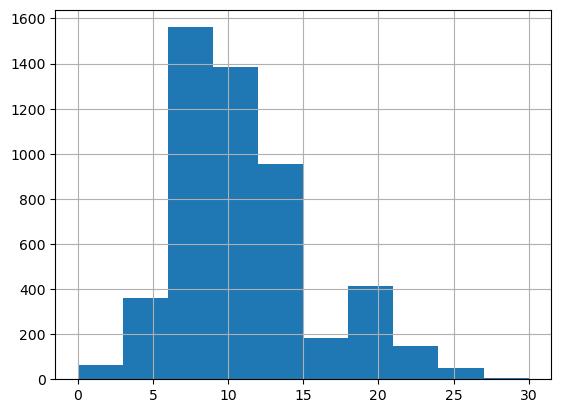

In [25]:
# Checking to see if 0s distort overall distribution 
civil_summons_2021.yrs_of_service.hist()

### Fixing Roster Race (American Indian) 

In [27]:
civil_summons_2021.roster_race.value_counts()

roster_race
WHITE              2146
HISPANIC           1513
ASIAN               736
BLACK               725
AMERICAN INDIAN       6
Name: count, dtype: int64

### Fixing Roster Gender

In [29]:
civil_summons_2021.roster_gender.value_counts()

roster_gender
MALE            4157
FEMALE           964
TGNC / OTHER       5
Name: count, dtype: int64

### Fixing Roster Rank

In [31]:
civil_summons_2021.roster_rank.value_counts()

roster_rank
POLICE OFFICER    3729
SERGEANT           745
DETECTIVE          643
LIEUTENANT           7
CAPTAIN              1
INSPECTOR            1
Name: count, dtype: int64

In [32]:
# Binary gender: MALE = 1, NOT MALE = 0
civil_summons_2021['roster_gender'] = (civil_summons_2021['roster_gender'] == 'MALE').astype(int)


# --- Race ---
civil_summons_2021['roster_race'] = civil_summons_2021['roster_race'].replace(
    {'AMERICAN INDIAN': 'OTHER', 'ASIAN': 'OTHER'}
)

civil_summons_2021['roster_race'] = pd.Categorical(
    civil_summons_2021['roster_race'],
    categories=['WHITE', 'BLACK', 'HISPANIC', 'OTHER']
)

# --- Rank ---
civil_summons_2021['roster_rank'] = civil_summons_2021['roster_rank'].replace(
    {'SERGEANT': 'SERGEANT+', 'LIEUTENANT': 'SERGEANT+', 
     'CAPTAIN': 'SERGEANT+', 'INSPECTOR': 'SERGEANT+'}
)
civil_summons_2021['roster_rank'] = pd.Categorical(
    civil_summons_2021['roster_rank'],
    categories=['POLICE OFFICER', 'DETECTIVE', 'SERGEANT+']  # POLICE OFFICER is baseline
)

# Verify
print(civil_summons_2021['roster_gender'].value_counts())
print(civil_summons_2021['roster_race'].value_counts())
print(civil_summons_2021['roster_rank'].value_counts())

roster_gender
1    4157
0     969
Name: count, dtype: int64
roster_race
WHITE       2146
HISPANIC    1513
OTHER        742
BLACK        725
Name: count, dtype: int64
roster_rank
POLICE OFFICER    3729
SERGEANT+          754
DETECTIVE          643
Name: count, dtype: int64


In [33]:
civil_summons_2021['Respondent Race'].value_counts()

Respondent Race
Unknown                    1353
Black                      1213
Hisp. White                 906
White                       816
Asian/Pacific Is.           535
Hisp. Black                 224
Am. Ind./Alaskan Native      59
2 or more races              15
Name: count, dtype: int64

### Clean total_award_count

In [35]:
display(civil_summons_2021[civil_summons_2021['total_award_count'].isnull()])

,Ticket_Number,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,cs_first,cs_middle,cs_last,pr_first,pr_middle,pr_last,...,yrs_of_service,oath_latitude,oath_longitude,CB2020,CT2020,BCTCB2020,Respondent Race,total_arrests,BoroName,total_calls
14,196385907,966888,MARITZA,TORRES,MARITZA,NaN,TORRES,NaN,NaN,NaN,...,0,40.687670,-73.951036,2000.0,24300.0,3.024300e+10,White,2.0,Brooklyn,64.0
20,196403498,960914,KEITH,MCGREEVY,KEITH,NaN,MCGREEVY,NaN,NaN,NaN,...,0,40.709491,-73.951106,3010.0,51300.0,3.051300e+10,White,0.0,Brooklyn,3.0
80,197998671,957044,JOEL,POLANCO,JOEL,NaN,POLANCO,JOEL,NaN,POLANCO,...,13,40.750160,-73.995261,1012.0,10300.0,1.010300e+10,Black,0.0,Manhattan,65.0
108,198345988,957091,EDUARDO,RODRIGUEZ,EDUARDO,NaN,RODRIGUEZ,NaN,NaN,NaN,...,0,40.826399,-73.950355,3000.0,22900.0,1.022900e+10,Hisp. White,4.0,Manhattan,53.0
116,198423592,923153,RYAN,SEFTON,RYAN,NaN,SEFTON,NaN,NaN,NaN,...,0,40.814147,-73.956497,1017.0,21900.0,1.021900e+10,White,10.0,Manhattan,232.0
183,198973390,964321,JORDAN,TOZITSKY,JORDAN,NaN,TOZITSKY,JORDAN,D,TOZITSKY,...,8,40.753061,-73.872160,3000.0,27302.0,4.027302e+10,Hisp. White,0.0,Queens,24.0
413,200264278,967441,MICHAEL,CANNATELLI,MICHAEL,NaN,CANNATELLI,MICHAEL,A,CANNATELLI,...,6,40.597932,-73.985490,2004.0,40400.0,3.040400e+10,Asian/Pacific Is.,0.0,Brooklyn,3.0
594,202110352,958908,RYAN,MCKENNA,RYAN,NaN,MCKENNA,RYAN,J,MCKENNA,...,10,40.755694,-73.912469,2001.0,16100.0,4.016100e+10,Hisp. White,0.0,Queens,16.0
765,208110550,917525,JEANMARC,DENIS,JEANMARC,NaN,DENIS,NaN,NaN,NaN,...,0,40.689758,-73.939404,2001.0,27900.0,3.027900e+10,Black,0.0,Brooklyn,6.0
852,211811427,917525,JEANMARC,DENIS,JEANMARC,NaN,DENIS,NaN,NaN,NaN,...,0,40.686316,-73.954264,3000.0,24300.0,3.024300e+10,Black,2.0,Brooklyn,30.0


In [36]:
# Missing awards likely means no awards that were merged in based on tex id from award data
civil_summons_2021['total_award_count'] = civil_summons_2021['total_award_count'].fillna(0)

### Checking missing values again 

In [38]:
missing = civil_summons_2021.isnull().sum()
print(missing[missing > 0])

cs_middle                           1328
pr_first                              65
pr_middle                           1407
pr_last                               65
O_Respondent_first_name              120
O_Respondent_last_name                 4
O_Violation_Location_City            397
O_Violation_Location_Zip_Code       3358
O_Violation_Location_State_Name      451
O_Hearing_Result                     918
O_Scheduled_Hearing_Location        1471
O_Hearing_Date                         3
O_Decision_Location_Borough         2249
O_Decision_Date                      924
O_Violation_Details                   24
O_Date_Judgment_Docketed            3718
O_violation_location_borough          16
O_violation_location_block_no       3717
O_violation_location_lot_no         3717
O_violation_location_house_no       3221
O_violation_location_street_name      32
O_violation_location_floor          5126
O_violation_location_city            412
O_violation_location_zip_code       3371
O_violation_loca

In [39]:
display(civil_summons_2021[civil_summons_2021['Respondent Race'].isnull()])

,Ticket_Number,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,cs_first,cs_middle,cs_last,pr_first,pr_middle,pr_last,...,yrs_of_service,oath_latitude,oath_longitude,CB2020,CT2020,BCTCB2020,Respondent Race,total_arrests,BoroName,total_calls
1149,202837865,964962,KRISTEN,CANDELARIA,KRISTEN,N,CANDELARIA,KRISTEN,N,CANDELARIA,...,8,40.701520,-73.886072,2002.0,62700.0,4.062700e+10,NaN,0.0,Queens,2.0
1560,206205762,958895,ROBERT,MAZZIOTTI,ROBERT,P,MAZZIOTTI,ROBERT,P,MAZZIOTTI,...,10,40.751010,-73.990615,1005.0,10900.0,1.010900e+10,NaN,5.0,Manhattan,2664.0
1676,211749762,959329,JUSTIN,VALENTIN,JUSTIN,C,VALENTIN,JUSTIN,C,VALENTIN,...,10,40.749804,-73.987762,1011.0,10900.0,1.010900e+10,NaN,2.0,Manhattan,3.0
1901,214540875,941927,MICHAEL,IGNATZ,MICHAEL,A,IGNATZ,MICHAEL,A,IGNATZ,...,19,40.713470,-73.959078,4000.0,52300.0,3.052300e+10,NaN,0.0,Brooklyn,13.0
3131,211741018,953330,ANDY,RODRIGUEZ,ANDY,J,RODRIGUEZ,ANDY,J,RODRIGUEZ,...,13,40.719402,-74.001890,2014.0,4700.0,1.004700e+10,NaN,1.0,Manhattan,33.0


In [40]:
civil_summons_2021['Respondent Race'] = civil_summons_2021['Respondent Race'].fillna('Unknown')

print(civil_summons_2021['Respondent Race'].value_counts())

Respondent Race
Unknown                    1358
Black                      1213
Hisp. White                 906
White                       816
Asian/Pacific Is.           535
Hisp. Black                 224
Am. Ind./Alaskan Native      59
2 or more races              15
Name: count, dtype: int64


In [41]:
missing = civil_summons_2021.isnull().sum()
print(missing[missing > 0])

cs_middle                           1328
pr_first                              65
pr_middle                           1407
pr_last                               65
O_Respondent_first_name              120
O_Respondent_last_name                 4
O_Violation_Location_City            397
O_Violation_Location_Zip_Code       3358
O_Violation_Location_State_Name      451
O_Hearing_Result                     918
O_Scheduled_Hearing_Location        1471
O_Hearing_Date                         3
O_Decision_Location_Borough         2249
O_Decision_Date                      924
O_Violation_Details                   24
O_Date_Judgment_Docketed            3718
O_violation_location_borough          16
O_violation_location_block_no       3717
O_violation_location_lot_no         3717
O_violation_location_house_no       3221
O_violation_location_street_name      32
O_violation_location_floor          5126
O_violation_location_city            412
O_violation_location_zip_code       3371
O_violation_loca

### Checking BoroName 
- Change to unknown 
- 204 NaNs: do not drop; needs to be added later 

In [43]:
display(civil_summons_2021[civil_summons_2021['BoroName'].isnull()])

,Ticket_Number,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,cs_first,cs_middle,cs_last,pr_first,pr_middle,pr_last,...,yrs_of_service,oath_latitude,oath_longitude,CB2020,CT2020,BCTCB2020,Respondent Race,total_arrests,BoroName,total_calls
6,196269581,963656,MARISSA,DINIS,MARISSA,L,DINIS,MARISSA,L,MONACO,...,8,40.751271,-73.703829,6003.0,157901.0,4.157902e+10,Asian/Pacific Is.,0.0,NaN,0.0
34,196590534,968253,MICHAEL,AZER,MICHAEL,NaN,AZER,MICHAEL,NaN,AZER,...,6,40.622452,-74.021645,1002.0,14200.0,3.014200e+10,White,0.0,NaN,0.0
62,197774720,958186,NELSON,YU,NELSON,H,YU,NELSON,H,YU,...,11,40.711589,-73.994278,5000.0,800.0,1.000800e+10,Asian/Pacific Is.,0.0,NaN,0.0
72,197889560,956957,SEEYEUNG,MOY,SEEYEUNG,NaN,MOY,SEEYEUNG,NaN,MOY,...,11,40.716180,-74.002575,1009.0,3100.0,1.003100e+10,Asian/Pacific Is.,0.0,NaN,0.0
98,198169869,967576,ANTHONY,LEWIS,ANTHONY,L,LEWIS,ANTHONY,L,LEWIS,...,6,40.750777,-73.968397,1003.0,8602.0,1.008602e+10,White,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5082,201287204,965076,ROCHELLA,EXETER,ROCHELLA,S,EXETER,ROCHELLA,S,EXETER,...,8,40.700781,-73.967024,1005.0,54300.0,3.054300e+10,Unknown,0.0,NaN,0.0
5100,201126339,946911,EDSON,DELVA,EDSON,NaN,DELVA,EDSON,NaN,DELVA,...,17,NaN,NaN,NaN,NaN,NaN,Unknown,0.0,NaN,0.0
5101,201126348,955491,STEVEN,SIERRA,STEVEN,T,SIERRA,STEVEN,T,SIERRA,...,12,NaN,NaN,NaN,NaN,NaN,Unknown,0.0,NaN,0.0
5114,199897803,961716,VANESSA,DAMBROSI,VANESSA,M,DAMBROSI,VANESSA,M,DAMBROSI,...,9,40.634157,-73.935170,1002.0,72600.0,3.072600e+10,White,0.0,NaN,0.0


In [44]:
civil_summons_2021['BoroName'] = civil_summons_2021['BoroName'].fillna('Unknown')

print(civil_summons_2021['BoroName'].value_counts())

BoroName
Manhattan        2174
Brooklyn         1307
Queens            825
Bronx             545
Unknown           204
Staten Island      71
Name: count, dtype: int64


In [45]:
civil_summons_2021['Respondent Race'].value_counts()

Respondent Race
Unknown                    1358
Black                      1213
Hisp. White                 906
White                       816
Asian/Pacific Is.           535
Hisp. Black                 224
Am. Ind./Alaskan Native      59
2 or more races              15
Name: count, dtype: int64

In [46]:
civil_summons_2021 = civil_summons_2021.rename(columns={'Respondent Race': 'respondent_race'})

In [47]:
civil_summons_2021.to_csv('data/civil_summons_2021_v8.csv', index=False)

In [48]:
# 5134 total summonses
civil_summons_2021.Ticket_Number.count()

5126